In [ ]:
import os

print("🔍 Recherche du dossier contenant les données...")
for root, dirs, files in os.walk('/kaggle/input'):
    if 'train' in dirs and 'valid' in dirs:
        print(f"🎯 Trouvé ! Ton chemin BASE exact est :")
        print(f"BASE = '{root}'")
        break

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import models, transforms, datasets
from torch.utils.data import DataLoader

print("✅ Imports OK")

# Sur Kaggle, les données importées sont toujours dans /kaggle/input/
# L'espace où tu as le droit de sauvegarder des fichiers est /kaggle/working/
BASE       = '/kaggle/input/datasets/stealthtechnologies/rock-classification/Rock Data'
MODEL_DIR  = '/kaggle/working'
MODEL_PATH = os.path.join(MODEL_DIR, 'resnet50_best.pth')
device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print(f"✅ Device : {device}")
print(f"✅ BASE   : {BASE}")

In [ ]:
train_transform = transforms.Compose([
    
    # Redimensionne l’image :
    # le plus petit côté devient 256 pixels
    transforms.Resize(256),

    # Découpe aléatoirement une région 224x224
    # → data augmentation
    # → force le modèle à apprendre différentes zones de l’image
    transforms.RandomCrop(224),

    # Retourne horizontalement l’image avec probabilité 0.5
    # → améliore la généralisation
    transforms.RandomHorizontalFlip(),

    # Retourne verticalement l’image avec probabilité 0.5
    # → utile si l’orientation verticale n’a pas d’importance
    transforms.RandomVerticalFlip(),

    # Rotation aléatoire entre -30° et +30°
    # → rend le modèle robuste aux orientations différentes
    transforms.RandomRotation(30),

    # Modifie aléatoirement :
    # - luminosité
    # - contraste
    # - saturation
    # → simule différentes conditions d’éclairage
    transforms.ColorJitter(
        brightness=0.3,
        contrast=0.3,
        saturation=0.2
    ),

    # Convertit parfois l’image en niveaux de gris (10%)
    # → empêche le modèle de dépendre uniquement des couleurs
    transforms.RandomGrayscale(p=0.1),

    # Convertit l’image PIL en tenseur PyTorch
    # Format : [C, H, W]
    # Valeurs : [0,255] → [0,1]
    transforms.ToTensor(),

    # Normalisation des pixels
    # Moyennes et écarts-types utilisés par ImageNet
    # → stabilise et accélère l’apprentissage
    transforms.Normalize(
        [0.485, 0.456, 0.406],   # mean RGB
        [0.229, 0.224, 0.225]    # std RGB
    )
])



val_transform = transforms.Compose([

    # Redimensionnement identique au train
    transforms.Resize(256),

    # Crop centré et non aléatoire
    # → garantit une évaluation stable/reproductible
    transforms.CenterCrop(224),

    # Conversion en tenseur
    transforms.ToTensor(),

    # Même normalisation que le train
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

print("✅ Transformations OK")

train_ds = datasets.ImageFolder(os.path.join(BASE, 'train'), train_transform)
valid_ds = datasets.ImageFolder(os.path.join(BASE, 'valid'), val_transform)
test_ds  = datasets.ImageFolder(os.path.join(BASE, 'test'),  val_transform)

train_loader = DataLoader(train_ds, batch_size=32, shuffle=True,  num_workers=2)
valid_loader = DataLoader(valid_ds, batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False, num_workers=2)

print(f"✅ Train : {len(train_ds)} images")
print(f"✅ Valid : {len(valid_ds)} images")
print(f"✅ Test  : {len(test_ds)} images")
print(f"✅ Classes : {train_ds.classes}")

✅ Transformations OK
✅ Train : 3687 images
✅ Valid : 351 images
✅ Test  : 174 images
✅ Classes : ['Basalt', 'Clay', 'Conglomerate', 'Diatomite', 'Shale-(Mudstone)', 'Siliceous-sinter', 'chert', 'gypsum', 'olivine-basalt']

In [ ]:
model = models.resnet50(weights='IMAGENET1K_V1')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Sequential(
    nn.Dropout(0.5),
    nn.Linear(model.fc.in_features, 9)
)

model     = model.to(device)
criterion = nn.CrossEntropyLoss()

print("✅ Modèle prêt")

### Phase A

In [ ]:

# Objectif de la Phase A: Transfer-Learning
# - Apprendre à la tête du modèle 
# - transformer les features générales en 9 classes

# On entraîne uniquement la dernière couche (classifier)
model.fc.requires_grad_(True)

optimizer = optim.Adam(model.fc.parameters(), lr=0.001)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=3, factor=0.5
)

EPOCHS_A     = 10
best_acc     = 0.0
patience_ctr = 0
PATIENCE     = 4
history      = {'train_loss': [], 'val_loss': [], 'val_acc': []}

print("=" * 55)
print("PHASE A — FC uniquement  lr=0.001")
print("=" * 55)

for epoch in range(EPOCHS_A):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            correct  += outputs.max(1)[1].eq(labels).sum().item()
            total    += labels.size(0)

    val_acc = 100. * correct / total
    tl = train_loss / len(train_loader)
    vl = val_loss   / len(valid_loader)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_acc'].append(val_acc)
    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc     = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH) 
        print(f"Epoch {epoch+1:02d}/{EPOCHS_A} — Train: {tl:.4f} — Val: {vl:.4f} — Acc: {val_acc:.2f}% ⭐")
    else:
        patience_ctr += 1
        print(f"Epoch {epoch+1:02d}/{EPOCHS_A} — Train: {tl:.4f} — Val: {vl:.4f} — Acc: {val_acc:.2f}%")

    if patience_ctr >= PATIENCE:
        print(f"⏹️  Early stopping epoch {epoch+1}")
        break

print(f"\n✅ Phase A terminée — Meilleure acc : {best_acc:.2f}%")

=======================================================
PHASE A — FC uniquement  lr=0.001
=======================================================
Epoch 01/10 — Train: 1.8068 — Val: 1.5048 — Acc: 46.15% ⭐
Epoch 02/10 — Train: 1.4916 — Val: 1.2870 — Acc: 57.83% ⭐
Epoch 03/10 — Train: 1.4227 — Val: 1.2862 — Acc: 54.70%
Epoch 04/10 — Train: 1.3636 — Val: 1.3121 — Acc: 57.26%
Epoch 05/10 — Train: 1.3408 — Val: 1.2411 — Acc: 55.27%
Epoch 06/10 — Train: 1.3171 — Val: 1.2083 — Acc: 57.55%
⏹️  Early stopping epoch 6

✅ Phase A terminée — Meilleure acc : 57.83%

### Phase B

In [ ]:

# Transfer Learning: fc
# Fine tuning layer4 (dernière partie de ResNet: concepts très spécifiques)

for param in model.layer4.parameters():
    param.requires_grad = True
model.fc.requires_grad_(True) # cette couche fc n’est plus celle d’ImageNet, c'est remplacée par celle de la phase A

optimizer = optim.Adam([
    {'params': model.layer4.parameters(), 'lr': 0.000005},
    {'params': model.fc.parameters(),     'lr': 0.00005},
])
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='max', patience=4, factor=0.3
)

EPOCHS_B     = 25
patience_ctr = 0
PATIENCE     = 6

print("=" * 55)
print("PHASE B — layer4 + FC  lr ultra conservateur")
print("=" * 55)

for epoch in range(EPOCHS_B):
    model.train()
    train_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        loss = criterion(model(images), labels)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    model.eval()
    val_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            val_loss += criterion(outputs, labels).item()
            correct  += outputs.max(1)[1].eq(labels).sum().item()
            total    += labels.size(0)

    val_acc = 100. * correct / total
    tl = train_loss / len(train_loader)
    vl = val_loss   / len(valid_loader)
    history['train_loss'].append(tl)
    history['val_loss'].append(vl)
    history['val_acc'].append(val_acc)
    scheduler.step(val_acc)

    if val_acc > best_acc:
        best_acc     = val_acc
        patience_ctr = 0
        torch.save(model.state_dict(), MODEL_PATH) # la sauvegarde du meilleur modèle basée sur l'accuracy de validation, le script va ignorer la fin désastreuse de la courbe bleue.
        print(f"Epoch {epoch+1:02d}/{EPOCHS_B} — Train: {tl:.4f} — Val: {vl:.4f} — Acc: {val_acc:.2f}% ⭐")
    else:
        patience_ctr += 1
        print(f"Epoch {epoch+1:02d}/{EPOCHS_B} — Train: {tl:.4f} — Val: {vl:.4f} — Acc: {val_acc:.2f}%")

    if patience_ctr >= PATIENCE:
        print(f"⏹️  Early stopping epoch {epoch+1}")
        break

print(f"\n✅ Meilleure accuracy finale : {best_acc:.2f}%")
print(f"✅ Modèle sauvegardé dans : {MODEL_PATH}")

=======================================================
PHASE B — layer4 + FC  lr ultra conservateur
=======================================================
Epoch 01/25 — Train: 1.2419 — Val: 1.1569 — Acc: 60.68% ⭐
Epoch 02/25 — Train: 1.1953 — Val: 1.1408 — Acc: 61.25% ⭐
Epoch 03/25 — Train: 1.1450 — Val: 1.1237 — Acc: 61.82% ⭐
Epoch 04/25 — Train: 1.1299 — Val: 1.1132 — Acc: 63.53% ⭐
Epoch 05/25 — Train: 1.0616 — Val: 1.0711 — Acc: 64.96% ⭐
Epoch 06/25 — Train: 1.0407 — Val: 1.0724 — Acc: 63.82%
Epoch 07/25 — Train: 1.0064 — Val: 1.0376 — Acc: 66.10% ⭐
Epoch 08/25 — Train: 0.9567 — Val: 1.0443 — Acc: 65.24%
Epoch 09/25 — Train: 0.9459 — Val: 1.0762 — Acc: 64.10%
Epoch 10/25 — Train: 0.8933 — Val: 1.0657 — Acc: 65.53%
Epoch 11/25 — Train: 0.9091 — Val: 1.0416 — Acc: 66.38% ⭐
Epoch 12/25 — Train: 0.8424 — Val: 1.0271 — Acc: 66.38%
Epoch 13/25 — Train: 0.8473 — Val: 1.0083 — Acc: 67.24% ⭐
Epoch 14/25 — Train: 0.8017 — Val: 1.0687 — Acc: 64.96%
Epoch 15/25 — Train: 0.7794 — Val: 1.0742 — Acc: 66.38%
Epoch 16/25 — Train: 0.7608 — Val: 1.0265 — Acc: 65.81%
Epoch 17/25 — Train: 0.7322 — Val: 1.0021 — Acc: 68.09% ⭐
Epoch 18/25 — Train: 0.7214 — Val: 1.0410 — Acc: 67.52%
Epoch 19/25 — Train: 0.7025 — Val: 1.0313 — Acc: 68.66% ⭐
Epoch 20/25 — Train: 0.6625 — Val: 1.0219 — Acc: 68.66%
Epoch 21/25 — Train: 0.6720 — Val: 1.0775 — Acc: 65.24%
Epoch 22/25 — Train: 0.6509 — Val: 1.0246 — Acc: 66.95%
Epoch 23/25 — Train: 0.6503 — Val: 1.0708 — Acc: 65.81%
Epoch 24/25 — Train: 0.6142 — Val: 1.0544 — Acc: 68.95% ⭐
Epoch 25/25 — Train: 0.5808 — Val: 1.0479 — Acc: 69.23% ⭐

✅ Meilleure accuracy finale : 69.23%
✅ Modèle sauvegardé dans : /kaggle/working/resnet50_best.pth

## Évaluation finale sur l'ensemble de Test

In [ ]:
# Recharger les meilleurs poids sauvegardés avant l'overfitting
model.load_state_dict(torch.load(MODEL_PATH))
model.eval() # Mettre le modèle en mode évaluation (désactive le dropout)

test_loss, correct, total = 0, 0, 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        test_loss += criterion(outputs, labels).item()
        correct  += outputs.max(1)[1].eq(labels).sum().item()
        total    += labels.size(0)

test_acc = 100. * correct / total
print(f"🎯 Accuracy finale sur l'ensemble de test: {test_acc:.2f}%")
print(f"📉 Loss finale sur l'ensemble de test: {test_loss/len(test_loader):.4f}")

🎯 Accuracy finale sur l'ensemble de test: 70.11%
📉 Loss finale sur l'ensemble de test: 0.9558

## Visualisation des courbes (Loss et Accuracy)

In [ ]:
import matplotlib.pyplot as plt

# Extraire les données de ton dictionnaire 'history'
train_losses = history['train_loss']
val_losses = history['val_loss']
val_accs = history['val_acc']
epochs = range(1, len(train_losses) + 1)

# Création d'une figure avec 2 graphiques côte à côte
plt.figure(figsize=(14, 5))

# Graphique 1 : Évolution des Pertes (Loss)
plt.subplot(1, 2, 1)
plt.plot(epochs, train_losses, 'b-', label='Perte Entraînement (Train Loss)')
plt.plot(epochs, val_losses, 'r-', label='Perte Validation (Val Loss)')
plt.title('Évolution de la fonction de perte')
plt.xlabel('Époques (Phases A + B)')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

# Graphique 2 : Évolution de la Précision (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(epochs, val_accs, 'g-', linewidth=2, label='Précision Validation')
plt.title('Évolution de la précision (Accuracy)')
plt.xlabel('Époques (Phases A + B)')
plt.ylabel('Accuracy (%)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

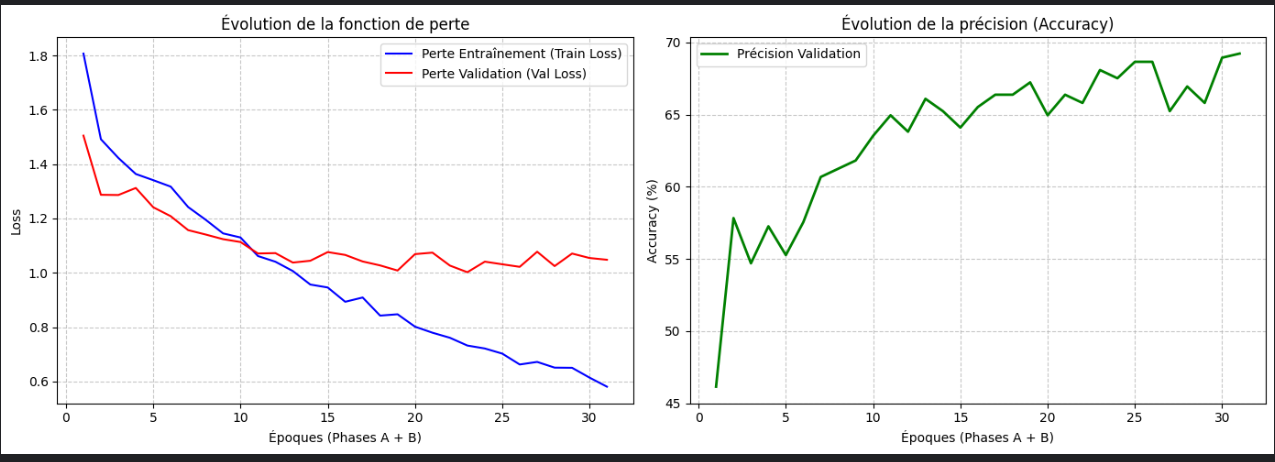

### Matrice de confusion

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

print("⏳ Calcul des prédictions pour la matrice de confusion...")

# S'assurer que le modèle est en mode évaluation
model.eval()

all_preds = []
all_labels = []

# Désactiver le calcul des gradients pour accélérer le processus
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        
        # Stocker les résultats
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcul mathématique de la matrice
cm = confusion_matrix(all_labels, all_preds)
classes_names = test_ds.classes # Récupère automatiquement les noms ['Basalt', 'Clay', ...]

# Affichage graphique avec Seaborn
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes_names, 
            yticklabels=classes_names,
            linewidths=.5, cbar_kws={"shrink": .75})

plt.title('Matrice de Confusion — GeoScanner (Dataset de Test)', fontsize=14, pad=15)
plt.xlabel('Prédictions de l\'IA', fontsize=12, labelpad=10)
plt.ylabel('Réalité Géologique', fontsize=12, labelpad=10)

# Rotation des labels pour qu'ils soient lisibles
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

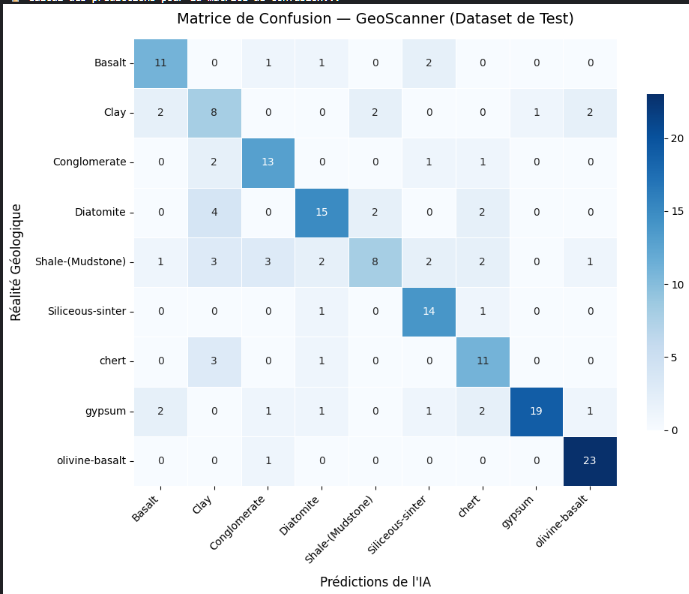


📊 RAPPORT DE CLASSIFICATION DÉTAILLÉ
============================================================
                  precision    recall  f1-score   support

          Basalt     0.6875    0.7333    0.7097        15
            Clay     0.4000    0.5333    0.4571        15
    Conglomerate     0.6842    0.7647    0.7222        17
       Diatomite     0.7143    0.6522    0.6818        23
Shale-(Mudstone)     0.6667    0.3636    0.4706        22
Siliceous-sinter     0.7000    0.8750    0.7778        16
           chert     0.5789    0.7333    0.6471        15
          gypsum     0.9500    0.7037    0.8085        27
  olivine-basalt     0.8519    0.9583    0.9020        24

        accuracy                         0.7011       174
       macro avg     0.6926    0.7020    0.6863       174
    weighted avg     0.7185    0.7011    0.6979       174


C'est la suite logique et indispensable ! La matrice de confusion est fantastique pour "voir" les erreurs, mais la **Précision**, le **Recall** (Rappel) et le **F1-Score** sont les vrais juges de paix en Data Science. Ce sont les chiffres exacts que tu mettras dans ton rapport final.

Dans un problème à 9 classes comme GeoScanner, on ne calcule pas juste une précision globale. On évalue la performance de l'IA **roche par roche**.

Voici l'explication simple de ce trio, appliquée à ton modèle :

### 1. La Précision (La qualité de la prédiction)

* **La question :** *« Quand le modèle affirme que c'est du Basalt, a-t-il souvent raison ? »*
* **L'explication :** C'est la capacité du modèle à ne pas faire de "fausses alertes" (Faux Positifs). Si la précision du *Siliceous-sinter* est basse, cela veut dire que le modèle a tendance à classer un peu tout et n'importe quoi dans cette catégorie quand il a un doute.
* **Formule mathématique :** $Vrais Positifs / (Vrais Positifs + Faux Positifs)$

### 2. Le Recall / Rappel (La quantité détectée)

* **La question :** *« Sur toutes les vraies photos d'Olivine-basalt de mon test, combien le modèle a-t-il réussi à en trouver ? »*
* **L'explication :** C'est la capacité du modèle à ne rater aucun échantillon (éviter les Faux Négatifs). Si le recall du *Conglomerate* est bas, cela veut dire que de nombreux vrais conglomérats sont passés sous le radar et ont été pris pour autre chose.
* **Formule mathématique :** $Vrais Positifs / (Vrais Positifs + Faux Négatifs)$

### 3. Le F1-Score (Le juste équilibre)

* **La question :** *« Quel est le score de fiabilité global pour cette roche ? »*
* **L'explication :** C'est la moyenne harmonique entre la Précision et le Recall. Il est extrêmement utile car il punit les modèles qui trichent. Par exemple, si ton IA prédisait "Basalt" 100% du temps, elle aurait un Recall de 100% pour le Basalt (elle les a tous trouvés), mais une Précision catastrophique (elle s'est trompée sur toutes les autres roches). Le F1-Score fait la balance.
* **Formule mathématique :** $2 \times \frac{Precision \times Recall}{Precision + Recall}$
